###   Крутки

In [12]:
import pandas as pd
import numpy as np

import matplotlib
import matplotlib.pyplot as plt
import random
import time


%matplotlib inline

In [13]:
#  Число экспериментов
n_exp = 50000

P4 = 0.051
Warranty4 = 10

Warranty_hero_1 = 75
Warranty_hero_2 = 90

base_hero_prob = 0.006
base_weapon_prob = 0.0075

Warranty_weapon_1 = 65
Warranty_weapon_2 = 80

after_increase_hero_prob = 0.3238 # c 75
after_increase_weapon_prob = 0.355 # c 65

### 1 эксперимент подсчета круток на ивентового 5* героя

In [14]:
def get_event_hero_exp(hard_warranty = False, roll_completed = 0,
                            p1 = base_hero_prob, p2 = after_increase_hero_prob):
    k_no_success = roll_completed
    is_hard_warranty = hard_warranty

    count_roll = 0
    for roll in range(1, 181):
        example = random.random()
        if example <= p1:
            if example*2 <= p1 or is_hard_warranty:
                return roll
            else:
                is_hard_warranty = True
            k_no_success = 0
        elif k_no_success >= Warranty_hero_1 and example <= p2:
            if 2*example <= p2 or is_hard_warranty:
                return roll
            else:
                is_hard_warranty = True
            k_no_success = 0
        elif k_no_success >= Warranty_hero_2 - 1:
            if example*2 <= 1 or is_hard_warranty:
                return roll
            else:
                is_hard_warranty = True
            k_no_success = 0
        else:
            k_no_success += 1
        count_roll += 1

    res[i] = count_roll
        
    return 180

### 1 эксперимент подсчета круток на ивентового 5* героя с констами

In [15]:
def get_event_hero_const_exp(hard_warranty = False, roll_completed = 0, count_const = 1):
    if count_const == 0:
        return 0
    roll = get_event_hero_exp(hard_warranty, roll_completed)
    
    for i in range(1, count_const):
        roll += get_event_hero_exp()
    return roll

### 1 эксперимент подсчета круток на ивентового 5* оружия

In [16]:
def get_event_weapon_exp(hard_warranty = False, roll_completed = 0,
                            p1 = base_weapon_prob, p2 = after_increase_weapon_prob):
    
    is_hard_warranty = hard_warranty
    k_no_success = roll_completed
    stuck_point = 0

    for roll in range(1, 241):
        example = random.random()
        if example <= p1:
            k_no_success = 0
            if example <= p1 * 0.75 or is_hard_warranty or stuck_point == 2:
                if random.random() <= 0.5 or stuck_point == 2:
                    return roll
                else:
                    stuck_point += 1
                is_hard_warranty=False
            else:
                stuck_point += 1
                is_hard_warranty=True
        elif k_no_success >= Warranty_weapon_1 and example <= p2:
            k_no_success = 0
            if example <= p2 * 0.75 or is_hard_warranty  or stuck_point == 2:
                if random.random() <= 0.5 or stuck_point == 2:
                    return roll
                else:
                    stuck_point += 1
                is_hard_warranty=False
            else:
                stuck_point += 1
                is_hard_warranty=True


        elif k_no_success == Warranty_weapon_2-1:
            k_no_success = 0
            example = random.random()
            if example <= 0.75 or is_hard_warranty or stuck_point == 2:
                if random.random() <= 0.5 or stuck_point == 2:
                    return roll
                else:
                    stuck_point += 1
                is_hard_warranty=False
            else:
                stuck_point += 1
                is_hard_warranty=True

        else:
            k_no_success += 1
            
    return 240

### 1 эксперимент подсчета круток на ивентового 5* оружия с констами

In [17]:
def get_event_weapon_const_exp(hard_warranty = False, roll_completed = 0, count_const = 1):
    if count_const == 0:
        return 0
    roll = get_event_weapon_exp(hard_warranty, roll_completed)
    
    for i in range(1, count_const):
        roll += get_event_weapon_exp()
    return roll

### число роллов для героя и его сигны

In [18]:
def count_roll_for_hero_sign(hard_warranty_hero = False, roll_completed_hero = 0, count_const = 0,
                             hard_warranty_weapon = False,  roll_completed_weapon = 0):
    res = np.empty(n_exp)
    
    for i in range(n_exp):
        res[i] = (get_event_hero_const_exp(hard_warranty_hero, roll_completed = roll_completed_hero, count_const = count_const)
            + get_event_weapon_const_exp(hard_warranty_weapon, roll_completed =roll_completed_weapon))

    data_frame = pd.DataFrame(res)
    data_frame_desc = data_frame.describe()
    return [res, data_frame, data_frame_desc]

### число роллов для героя

In [19]:
def count_roll_for_hero(hard_warranty = False, roll_completed = 0, count_const = 0):
    res = np.empty(n_exp)
    
    for i in range(n_exp):
        res[i] = get_event_hero_const_exp(hard_warranty, roll_completed = roll_completed, count_const = count_const)

    data_frame = pd.DataFrame(res)
    data_frame_desc = data_frame.describe()
    return [res, data_frame, data_frame_desc]

### Мой скам

In [20]:
def scum_func(count_hero, count_weapon):
    res = np.empty(n_exp)
    
    for i in range(n_exp):
        res[i] = (get_event_hero_const_exp(hard_warranty = False, roll_completed = 0, count_const = count_hero)
            + get_event_weapon_const_exp(hard_warranty = False, roll_completed = 0, count_const = count_weapon))

    data_frame = pd.DataFrame(res)
    data_frame_desc = data_frame.describe()
    return [res, data_frame, data_frame_desc]

In [21]:
# main 51 + 7
# twin 38 + 5
# since sumery
# main 14 (+2) + 3
# twin 12 + 1
# nina 27 + 4; 2480 + 343

start_time = time.time()
q, frame, w = scum_func(count_hero = 38, count_weapon = 5)
sorted = frame.sort_values(by=[0])
end_time = time.time()
frame.quantile([0.10, 0.20, .40, .50, .55, .60, .65, .70, .75, .80, .85, .90, .95, .99, .999, 1])

,0
0.100,3728.000
0.200,3858.000
0.400,4034.000
0.500,4109.000
0.550,4146.000
0.600,4184.000
0.650,4222.000
0.700,4263.000
0.750,4307.000
0.800,4356.000


In [22]:
print("--- %s seconds ---" % (end_time - start_time))

--- 29.585272073745728 seconds ---


In [17]:
# main
len(sorted[sorted[0] <= (4786+732)])/50000

0.46918

In [20]:
# twin
len(sorted[sorted[0] <= (3363+698)])/50000

0.4429

In [15]:
# all 7172
len(sorted[sorted[0] <= (3805+693-85-68 +2926+520-67)])/50000

0.95762

In [16]:
# all since sumeru + 2 nahida
len(sorted[sorted[0] <= (1630+350+85+1437+198)])/50000

0.99482

In [20]:
# nina
len(sorted[sorted[0] <= (2480+343)])/50000

0.04402

In [1]:
# all since sumeru
print(4+74+44+75+78+53+82+65+67+75+82+48+79+74+79+75+78+62+76+78+74+80+80+48)
print(67+66+65+25+64+63)
print(74+75+77+37+86+75+79+77+77+42+78+2+79+74+76+74+76+77+76+79+8+39)
print(65+65+68)

1630
350
1437
198


### Яэ + Али

In [35]:
#q, frame, w = count_roll_for_hero_sign(hard_warranty_hero = True, roll_completed_hero = 58, count_const = 3,
#                             hard_warranty_weapon = False,  roll_completed_weapon = 0)

q, frame, w = count_roll_for_hero(hard_warranty = False, roll_completed = 0, count_const = 5)
frame.quantile([0.10, 0.20, .40, .50, .55, .60, .65, .70, .75, .80, .85, .90, .95, .99, .999, 1])

# 122 (132) в начале
# 167 (181) в середине
# 212 (235) в конце

,0
0.100,345.000
0.200,388.000
0.400,445.000
0.500,471.000
0.550,482.000
0.600,495.000
0.650,508.000
0.700,523.000
0.750,539.000
0.800,553.000


In [30]:
sorted = frame.sort_values(by=[0])

In [15]:
len(sorted[sorted[0] <= 244])/50000

0.92714

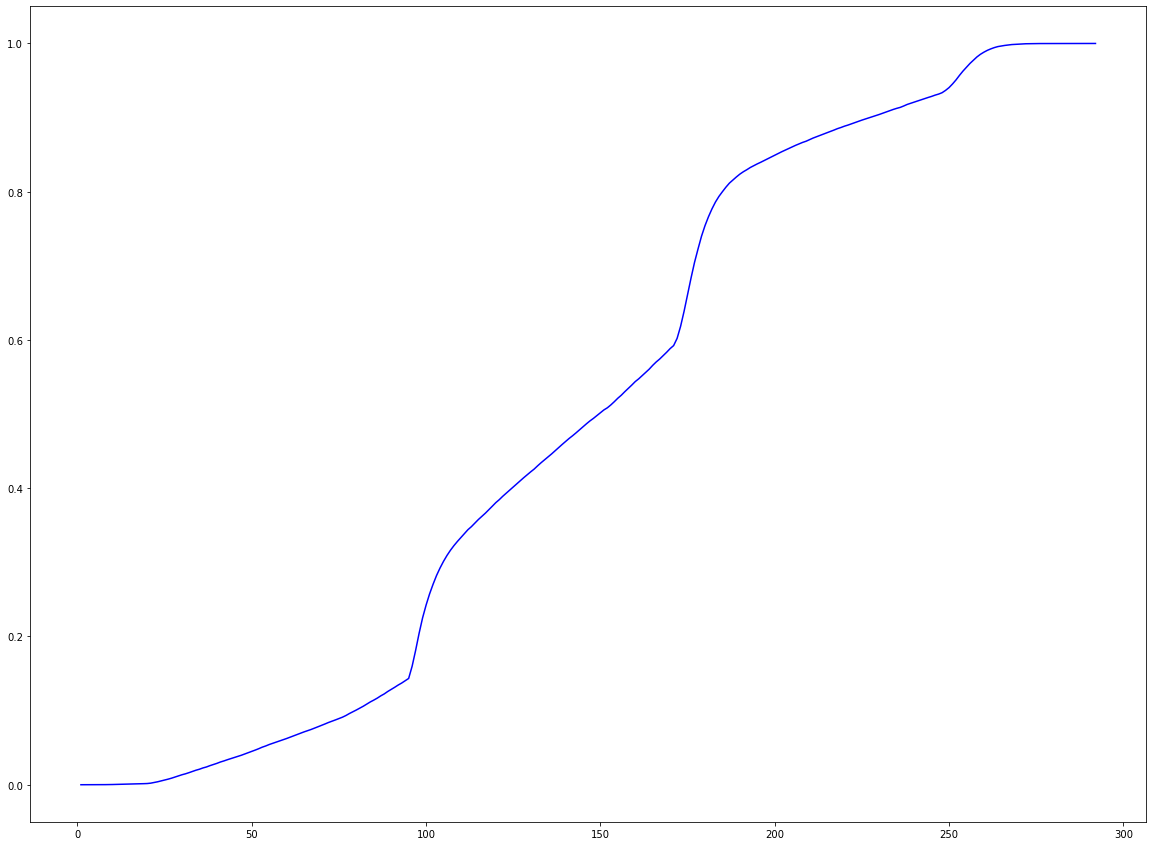

In [13]:
x=[]
y=[]
i = 1
prob = 0
while prob < 1:
    prob = len(sorted[sorted[0] <= i])/50000
    x.append(i)
    y.append(prob)
    i+=1
    

plt.figure(figsize=(20, 15))
plt.plot(x, y, color ='blue')

### Арлекино + сигна

In [37]:
q, frame, w = count_roll_for_hero_sign(hard_warranty_hero = False, roll_completed_hero = 52, count_const = 7,
                             hard_warranty_weapon = False,  roll_completed_weapon = 28)
frame.quantile([0.10, 0.20, .40, .50, .55, .60, .65, .70, .75, .80, .85, .90, .95, .99])

,0
0.10,549.0
0.20,603.0
0.40,676.0
0.50,707.0
0.55,723.0
0.60,740.0
0.65,756.0
0.70,773.0
0.75,793.0
0.80,815.0


In [24]:
sorted = frame.sort_values(by=[0])
len(sorted[sorted[0] <= 455])/50000 # в начале патча с2 р1

0.91598

In [25]:
len(sorted[sorted[0] <= 508])/50000 # в конце патча с2 р1

0.97532

In [29]:
sorted = frame.sort_values(by=[0])
len(sorted[sorted[0] <= 455])/50000 # в начале патча с3 р1

0.62446

In [30]:
len(sorted[sorted[0] <= 508])/50000 # в конце патча с3 р1

0.79346

In [32]:
sorted = frame.sort_values(by=[0])
len(sorted[sorted[0] <= 455])/50000 # в начале патча с4 р1

0.27834

In [33]:
len(sorted[sorted[0] <= 508])/50000 # в конце патча с4 р1

0.4576

In [38]:
sorted = frame.sort_values(by=[0])
len(sorted[sorted[0] <= 455])/50000 # в начале патча с6 р1

0.0192

In [39]:
len(sorted[sorted[0] <= 508])/50000 # в конце патча с6 р1

0.05254

In [17]:
q, frame, w = count_roll_for_hero_sign(hard_warranty_hero = False, roll_completed_hero = 13, count_const = 2,
                             hard_warranty_weapon = False,  roll_completed_weapon = 10)
frame.quantile([0.10, 0.20, .40, .50, .55, .60, .65, .70, .75, .80, .85, .90, .95, .99])

,0
0.10,176.0
0.20,208.0
0.40,259.0
0.50,278.0
0.55,286.0
0.60,298.0
0.65,310.0
0.70,324.0
0.75,337.0
0.80,349.0


In [18]:
sorted = frame.sort_values(by=[0])
len(sorted[sorted[0] <= 285+25])/50000 # в начале патча с1 р1

0.65088

In [19]:
len(sorted[sorted[0] <= 336+30])/50000 # в конце патча с1 р1

0.8581

In [23]:
q, frame, w = count_roll_for_hero_sign(hard_warranty_hero = False, roll_completed_hero = 13, count_const = 3,
                             hard_warranty_weapon = False,  roll_completed_weapon = 10)
frame.quantile([0.10, 0.20, .40, .50, .55, .60, .65, .70, .75, .80, .85, .90, .95, .99])

,0
0.10,257.0
0.20,295.0
0.40,350.0
0.50,371.0
0.55,384.0
0.60,396.0
0.65,410.0
0.70,423.0
0.75,435.0
0.80,451.0


In [24]:
sorted = frame.sort_values(by=[0])
len(sorted[sorted[0] <= 285+25])/50000 # в начале патча с2 р1

0.25124

In [25]:
len(sorted[sorted[0] <= 336+30])/50000 # в конце патча с2 р1

0.48048

### 4* hero

In [60]:
def prob_get_event_4(roll, hard_warranty = False, roll_completed = 0):
    res = np.empty(n_exp)
    
    for i in range(n_exp):
        is_hard_warranty = hard_warranty
        k_success=0
        k_no_success = roll_completed
       
        for j in range(roll):
            example = random.random()
            if example <= P4:
                k_no_success = 0
                if 2*example <= P4 or is_hard_warranty:
                    k_success += 1
                    is_hard_warranty=False
                else:
                    is_hard_warranty=True
            elif k_no_success == Warranty4-1:
                k_no_success = 0
                example = random.random()
                if 2*example <= 1 or is_hard_warranty:
                    k_success += 1
                    is_hard_warranty=False
                else:
                    is_hard_warranty=True
            else:
                k_no_success += 1

        res[i] = k_success
        
    data_frame = pd.DataFrame(res)
    data_frame_desc = data_frame.describe()
    #data_frame_desc.loc[str(55) + "%"] = data_frame.quantile(0.55)
    return [res, data_frame, data_frame_desc]

In [62]:
def prob_get_4(roll, roll_completed = 0):
    res = np.empty(n_exp)
    
    for i in range(n_exp):
        k_success=0
        k_no_success = roll_completed
       
        for j in range(roll):
            example = random.random()
            if example <= P4:
                k_no_success = 0
                k_success += 1
            elif k_no_success == Warranty4-1:
                k_no_success = 0
                k_success += 1
            else:
                k_no_success += 1

        res[i] = k_success
        
    data_frame = pd.DataFrame(res)
    data_frame_desc = data_frame.describe()
    #data_frame_desc.loc[str(55) + "%"] = data_frame.quantile(0.55)
    return [res, data_frame, data_frame_desc]